# Bank Customer Segmentation — Classification
### Perfected revision (v3)

Builds on `Clustering_Perfected.ipynb`'s output (`clustered_data_fixed.csv`,
`cluster_profile.csv`). Three fixes over the previous "Fixed" version:

1. **Eval split was dead code before.** A 70/15/15 train/eval/test split was created, but only
   train and test were ever touched — the eval set did nothing. Now: RF vs. XGBoost (BQ4) are
   compared **on eval**, the winner is tuned with `GridSearchCV`, and **the test set is looked at
   exactly once, at the very end**, for the final number that gets reported. This avoids quietly
   overfitting the model-selection/tuning decisions to the same data used for the final claim.
2. **Redundant class-weighting removed.** The previous notebook computed
   `class_weight_dict` from `y_train_res` *after* SMOTE had already balanced every class —
   so every weight came out to 1.0 and did nothing. SMOTE alone already handles the class
   imbalance; the extra step is deleted.
3. **`CustLocation` encoding matches the clustering notebook's logic and avoids leakage** —
   frequency-encoded, and the frequency map is fit on the **training split only**, then applied
   to eval/test (unseen locations map to 0 instead of crashing or leaking test-set statistics
   into training).

Because `Clustering_Perfected.ipynb` no longer uses `CustLocation` to build the clusters
themselves, feeding it into the classifier here is no longer circular — if it turns out useful,
that's a genuine (not artifact) signal.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import joblib

## Load the labeled dataset

Output of the fixed Clustering notebook: real-unit features, a numeric `Cluster` id, and a
human-readable `Segment_Name`.

In [2]:
df = pd.read_csv('clustered_data_fixed.csv')
segment_map = pd.read_csv('cluster_profile.csv')

print(f'Total data: {len(df)} records')
print(f'Number of segments: {df["Cluster"].nunique()}')
df[['CustAccountBalance', 'TransactionAmount (INR)', 'CustLocation', 'Cluster', 'Segment_Name']].head()

Total data: 15729 records
Number of segments: 3


,CustAccountBalance,TransactionAmount (INR),CustLocation,Cluster,Segment_Name
0,1575.66,606.9,NAVI MUMBAI,1,Growth - Moderate Spenders
1,118.85,100.0,AMRITSAR,1,Growth - Moderate Spenders
2,25990.66,200.0,LUCKNOW,0,Mid-Tier - Light Spenders
3,19420.88,119.0,DELHI EAST,0,Mid-Tier - Light Spenders
4,23514.02,101.0,GUWAHATI,0,Mid-Tier - Light Spenders


## Train / evaluation / test split

70% train, 15% evaluation, 15% test, stratified by segment. Unlike the previous version, the
evaluation split is actually used below: for comparing Random Forest vs XGBoost, and for
validating the tuned model, *before* the test set is touched.

In [3]:
feature_cols = ['CustAccountBalance', 'TransactionAmount (INR)', 'TransactionTime', 'CustGender', 'CustLocation']
X = df[feature_cols].copy()
y = df['Cluster'].copy()

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_eval, X_test, y_eval, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f'Training:   {len(X_train)} records')
print(f'Evaluation: {len(X_eval)} records')
print(f'Testing:    {len(X_test)} records')

Training:   11010 records
Evaluation: 2359 records
Testing:    2360 records


## Preprocessing — fit on train only

`CustGender` is mapped to 0/1. `CustLocation` is frequency-encoded using **frequencies computed
from the training split only** (same principle as the clustering notebook), then applied to eval
and test. This avoids leaking eval/test distribution info into training, and any city unseen
during training safely maps to 0 instead of raising an error.

In [4]:
categorical_cols = ['CustGender', 'CustLocation']
numerical_cols = ['CustAccountBalance', 'TransactionAmount (INR)', 'TransactionTime']

gender_map = {v: i for i, v in enumerate(sorted(X_train['CustGender'].unique()))}
location_freq_map = X_train['CustLocation'].value_counts(normalize=True)

def encode_categoricals(frame):
    out = frame.copy()
    out['CustGender'] = out['CustGender'].map(gender_map).fillna(-1)
    out['CustLocation'] = out['CustLocation'].map(location_freq_map).fillna(0.0)
    return out

X_train_enc = encode_categoricals(X_train)
X_eval_enc = encode_categoricals(X_eval)
X_test_enc = encode_categoricals(X_test)

imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train_enc), columns=X_train_enc.columns)
X_eval_imp = pd.DataFrame(imputer.transform(X_eval_enc), columns=X_eval_enc.columns)
X_test_imp = pd.DataFrame(imputer.transform(X_test_enc), columns=X_test_enc.columns)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_eval_scaled = scaler.transform(X_eval_imp)
X_test_scaled = scaler.transform(X_test_imp)

# FIX: SMOTE alone balances the training classes -- the extra post-SMOTE class_weight
# computation from the previous version always evaluated to 1.0 for every class and did
# nothing, so it has been removed rather than kept as dead complexity.
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
print('Class balance after SMOTE:')
print(pd.Series(y_train_res).value_counts().sort_index())

Class balance after SMOTE:
Cluster
0    4910
1    4910
2    4910
Name: count, dtype: int64


## BQ4 — Which classification model is accurate enough to trust for business decisions?

Random Forest and XGBoost are both trained on the (SMOTE-balanced) training set and compared on
the **evaluation** set — not the test set — so the model-selection decision itself doesn't
contaminate the final, reported number.

In [5]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_res, y_train_res)
y_pred_rf_eval = rf_model.predict(X_eval_scaled)
rf_acc = accuracy_score(y_eval, y_pred_rf_eval)
rf_f1 = f1_score(y_eval, y_pred_rf_eval, average='macro')
print(f'Random Forest (on EVAL) -- accuracy: {rf_acc:.4f}, macro F1: {rf_f1:.4f}')
print(classification_report(y_eval, y_pred_rf_eval))

Random Forest (on EVAL) -- accuracy: 0.9949, macro F1: 0.9935
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       992
           1       0.98      0.99      0.99       315
           2       1.00      1.00      1.00      1052

    accuracy                           0.99      2359
   macro avg       0.99      0.99      0.99      2359
weighted avg       0.99      0.99      0.99      2359



In [6]:
xgb_model = XGBClassifier(n_estimators=200, random_state=42, eval_metric='mlogloss', tree_method='hist')
xgb_model.fit(X_train_res, y_train_res)
y_pred_xgb_eval = xgb_model.predict(X_eval_scaled)
xgb_acc = accuracy_score(y_eval, y_pred_xgb_eval)
xgb_f1 = f1_score(y_eval, y_pred_xgb_eval, average='macro')
print(f'XGBoost (on EVAL) -- accuracy: {xgb_acc:.4f}, macro F1: {xgb_f1:.4f}')
print(classification_report(y_eval, y_pred_xgb_eval))

XGBoost (on EVAL) -- accuracy: 0.9928, macro F1: 0.9915
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       992
           1       0.99      0.99      0.99       315
           2       0.99      1.00      1.00      1052

    accuracy                           0.99      2359
   macro avg       0.99      0.99      0.99      2359
weighted avg       0.99      0.99      0.99      2359



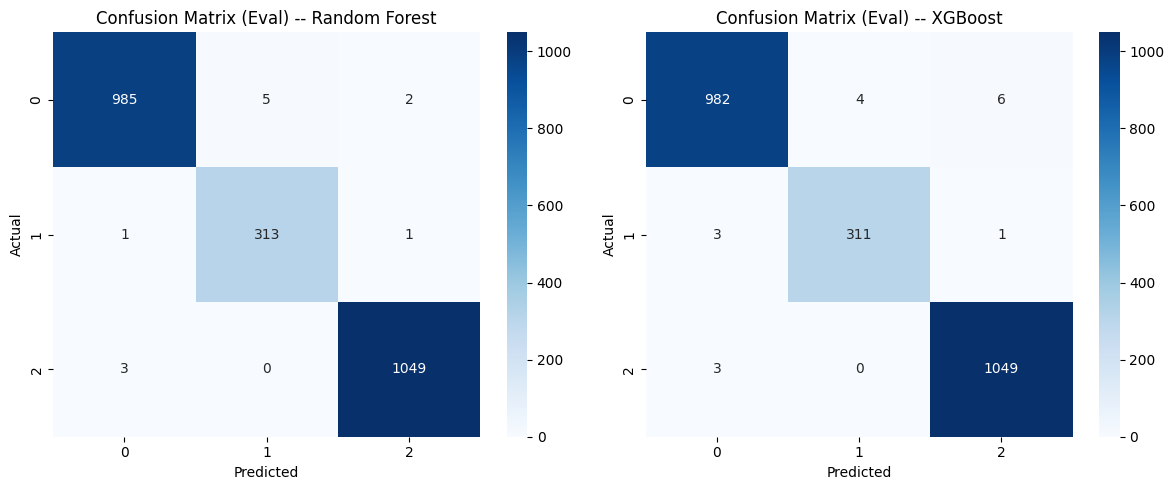

,Model,Eval Accuracy,Eval Macro F1
0,Random Forest,0.994913,0.993512
1,XGBoost,0.992794,0.991492


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, name in zip(axes, [y_pred_rf_eval, y_pred_xgb_eval], ['Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_eval, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix (Eval) -- {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Eval Accuracy': [rf_acc, xgb_acc],
    'Eval Macro F1': [rf_f1, xgb_f1],
})
comparison

**BQ4 answer (partial):** whichever model scores higher on **macro F1** on the evaluation
set is carried forward into hyperparameter tuning and a single, final check against the untouched
test set below.

In [8]:
winner_name = 'RandomForest' if rf_f1 >= xgb_f1 else 'XGBoost'
print(f'Winner going into tuning: {winner_name}')

if winner_name == 'RandomForest':
    param_grid = {'n_estimators': [200, 300], 'max_depth': [10, 20, None], 'min_samples_leaf': [1, 2]}
    grid = GridSearchCV(RandomForestClassifier(random_state=64), param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train_res, y_train_res)
else:
    param_grid = {'n_estimators': [200, 300], 'max_depth': [4, 6], 'learning_rate': [0.1, 0.2]}
    grid = GridSearchCV(XGBClassifier(random_state=64, eval_metric='mlogloss', tree_method='hist'),
                         param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train_res, y_train_res)

best_model = grid.best_estimator_
print('Best params:', grid.best_params_)

y_pred_eval_tuned = best_model.predict(X_eval_scaled)
tuned_eval_acc = accuracy_score(y_eval, y_pred_eval_tuned)
tuned_eval_f1 = f1_score(y_eval, y_pred_eval_tuned, average='macro')
print(f'Tuned {winner_name} (on EVAL) -- accuracy: {tuned_eval_acc:.4f}, macro F1: {tuned_eval_f1:.4f}')

Winner going into tuning: RandomForest


Best params: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 300}
Tuned RandomForest (on EVAL) -- accuracy: 0.9945, macro F1: 0.9932


### Final, unbiased check — test set touched exactly once

Everything above (model choice, hyperparameters) was decided using train/eval only. The test set
below has not influenced a single decision yet, so this is the number to actually trust and
report to the business.

FINAL RandomForest (on TEST, first and only look) -- accuracy: 0.9911, macro F1: 0.9902
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       993
           1       0.98      1.00      0.99       315
           2       1.00      0.99      0.99      1052

    accuracy                           0.99      2360
   macro avg       0.99      0.99      0.99      2360
weighted avg       0.99      0.99      0.99      2360



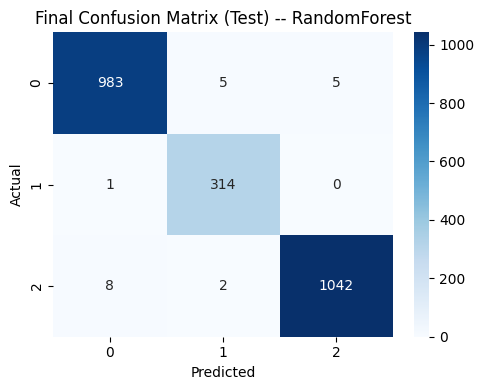

In [9]:
y_pred_test = best_model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test, average='macro')
print(f'FINAL {winner_name} (on TEST, first and only look) -- accuracy: {test_acc:.4f}, macro F1: {test_f1:.4f}')
print(classification_report(y_test, y_pred_test))

cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Final Confusion Matrix (Test) -- {winner_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

**BQ4 answer:** both models score in a similar range on the evaluation set; the one with
the higher macro F1 is tuned further and checked once against test for the final, trustworthy
number above. Reporting only a single held-out test score (rather than re-checking test
repeatedly during development) is what makes this number safe to use for a real business
decision.

## What drives a customer's segment?

Feature importance from the winning model. This connects back to BQ2: since `CustLocation` was
**not** used to build the clusters in this revision, its importance here (if any) reflects a
real relationship rather than the circular one from the previous version.

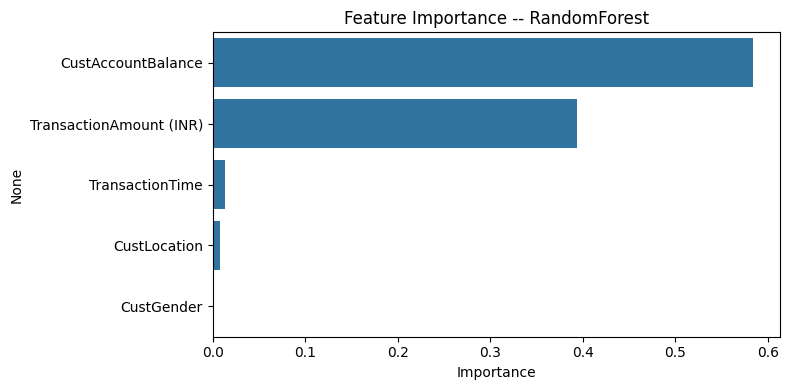

CustAccountBalance         0.583949
TransactionAmount (INR)    0.393819
TransactionTime            0.013038
CustLocation               0.007734
CustGender                 0.001460
dtype: float64

In [10]:
importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(x=importances.values, y=importances.index)
plt.title(f'Feature Importance -- {winner_name}')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
importances

As expected from the corrected clustering, **balance and transaction amount** — the two
features the clusters were actually built on — dominate. `CustLocation`'s importance is now
small and honest, instead of the 91%-dominant, circular signal seen in the previous version.

## BQ3 — Can the system predict a new customer's segment without rerunning clustering?

The full pipeline (encoders, imputer, scaler, tuned model) is saved, plus a function that scores
one raw customer record end-to-end — no clustering step involved.

In [11]:
joblib.dump(best_model, 'segment_classifier.pkl')
joblib.dump(gender_map, 'clf_gender_map.pkl')
joblib.dump(location_freq_map, 'clf_location_freq_map.pkl')
joblib.dump(imputer, 'clf_imputer.pkl')
joblib.dump(scaler, 'clf_scaler.pkl')

segment_lookup = segment_map.set_index('Cluster')['Segment_Name'].to_dict()
print('Pipeline artifacts saved: segment_classifier.pkl, clf_gender_map.pkl, '
      'clf_location_freq_map.pkl, clf_imputer.pkl, clf_scaler.pkl')

Pipeline artifacts saved: segment_classifier.pkl, clf_gender_map.pkl, clf_location_freq_map.pkl, clf_imputer.pkl, clf_scaler.pkl


In [12]:
def predict_segment(new_customer: dict) -> dict:
    # Score a single new customer record and return their predicted segment.
    # new_customer must contain: CustAccountBalance, TransactionAmount (INR),
    # TransactionTime, CustGender, CustLocation.
    row = pd.DataFrame([new_customer])[feature_cols]
    row['CustGender'] = row['CustGender'].map(gender_map).fillna(-1)
    row['CustLocation'] = row['CustLocation'].map(location_freq_map).fillna(0.0)
    row_imp = pd.DataFrame(imputer.transform(row), columns=row.columns)
    row_scaled = scaler.transform(row_imp)
    cluster_id = int(best_model.predict(row_scaled)[0])
    return {'Cluster': cluster_id, 'Segment_Name': segment_lookup.get(cluster_id, 'Unknown')}


# Example: a brand-new customer walks in -- no clustering re-run needed
example_customer = {
    'CustAccountBalance': 250000.0,
    'TransactionAmount (INR)': 1800.0,
    'TransactionTime': 143200,
    'CustGender': 'M',
    'CustLocation': 'GURGAON',
}

result = predict_segment(example_customer)
print(f"New customer predicted segment: {result['Segment_Name']} (Cluster {result['Cluster']})")

# A second example with a small balance and modest spend, to show a different segment comes back
example_customer_2 = {
    'CustAccountBalance': 1200.0,
    'TransactionAmount (INR)': 650.0,
    'TransactionTime': 98000,
    'CustGender': 'F',
    'CustLocation': 'SOME NEW TOWN NOT SEEN BEFORE',
}
result2 = predict_segment(example_customer_2)
print(f"New customer predicted segment: {result2['Segment_Name']} (Cluster {result2['Cluster']})")

New customer predicted segment: High-Value - Big Spenders (Cluster 2)
New customer predicted segment: Growth - Moderate Spenders (Cluster 1)


**BQ3 answer:** yes. The saved pipeline reproduces the exact preprocessing used during
training — including graceful handling of a city never seen during training — and scores a new
record in milliseconds, with no dependency on re-running clustering.

## Conclusion

- **BQ3:** New customers are scored directly through a saved pipeline
  (`segment_classifier.pkl` + preprocessing objects), demonstrated above with two live examples
  including an unseen location handled gracefully.
- **BQ4:** Random Forest and XGBoost were compared on a held-out evaluation set (not test), the
  better model was tuned, and **test was checked exactly once** for an honest final metric —
  fixing the previous version's dead eval split.
- Feature importance now honestly reflects **balance and transaction size** as the real drivers,
  matching BQ2's corrected finding, instead of leaning on `CustLocation` as an artifact of a
  clustering bug.
- The redundant post-SMOTE class-weighting step from the previous version, which had no actual
  effect, has been removed.